**FUNDAMENTAL OF COST FUNCTION FOR LINEAR REGRESSION MODEL**

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from utils import sigmoid
import copy
import math

In [9]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])                                           #(m,)

**Classifying the categories**


In [10]:
pos = y_train==1
neg = y_train == 0


**Plotting the diagram**

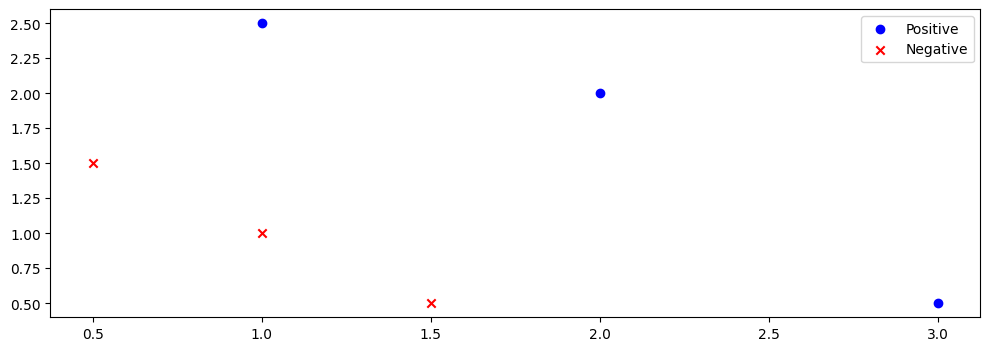

In [11]:
plt.figure(figsize = (12,4))
plt.scatter(X_train[pos,0],X_train[pos,1],marker='o',c='b',label='Positive')  #this is our positive class, and we are selecting the training data where the output y is positive
plt.scatter(X_train[neg,0],X_train[neg,1],marker='x',c='r',label='Negative') #this is our negative class, and we are selecting the training data where the output y is negative
plt.legend()
plt.show()

**Computing cost logistic**

In [12]:
def cost_logistic(x,y,w,b,sigmoid):
    m,n = x.shape
    total_cost = 0
    for i in range(m):
        pred_y=np.dot(x[i],w) + b
        sigmoid_value = sigmoid(pred_y)
        total_cost+= -y[i] * np.log(sigmoid_value) - (1-y[i]) * np.log(1-sigmoid_value)
    return total_cost/m
w_tmp = np.array([1,1])
b_tmp = -3
print(cost_logistic(X_train, y_train, w_tmp, b_tmp,sigmoid))      

0.36686678640551745


**Parital derivatives of the cost function with respect to the parameters of the model**

In [16]:
m,n = X_train.shape
w_init = np.zeros(n)
b_init  = 0
def gradient(x,y,w,b):
    m,n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0
    for i in range(m):
        pred_y = sigmoid(np.dot(x[i],w) + b)
        error = pred_y - y[i]
        for j in range(n):
            dj_dw[j]+=error*x[i,j]
        dj_db+=error
    return dj_dw/m,dj_db/m
    
        

**Gradient Descent to fit the model**

In [21]:
def gradient_descent(x,y,w_init,b_init,gradient,cost_function,alpha,iterations):
    m,n =x.shape
    w = copy.deepcopy(w_init)
    b= b_init
    cost_history = []
    iterations_history = []
    for i in range(iterations):
        dj_dw,dj_db = gradient(x,y,w,b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost = cost_function(x,y,w,b,sigmoid)  #computing the cost function with each updated parameters of the model
        if i % math.ceil(iterations/10) == 0:  #at every 100 iteration we are appending the cost value and the iteration value
            cost_history.append(cost)
            iterations_history.append(i)
    return w,b,cost_history,iterations_history
w_init  = np.zeros_like(X_train[0])
b_init = 0.
alpha = 0.1
iterations = 10000
final_w,final_b,cost_history,iterations_history = gradient_descent(X_train,y_train,w_init,b_init,gradient,cost_logistic,alpha,iterations)    
print(f'The parameters of the trained logistic regression model is w:{final_w} and b:{final_b}')          

The parameters of the trained logistic regression model is w:[5.28123029 5.07815608] and b:-14.222409982019837


**Observing the learning curve**

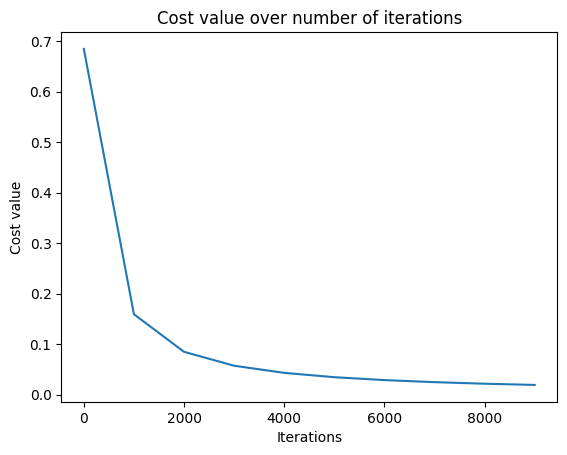

In [23]:
plt.plot(iterations_history,cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost value')
plt.title('Cost value over number of iterations')
plt.show()

**As we can observe from the learning curve above that , the cost function is decreasing over number of iterations , and after about 5000 iterations , the value of cost function is converging**